# Liu (2025) Cross-Sectional Recreation

Verbatim recreation of Liu et al. 2025 Figures 2 and 3 using the cross-sectional sample (last session per patient, first session per control).

**Figures produced:**
- Fig 2C–H — Per-subject ROI peak scatter (MNI space)
- Fig 2I    — Crawford's modified *t* per patient (ventral x-coord)
- Fig 2J    — Control null distribution (leave-one-out)
- Fig 3A/B  — Example RDMs (control lSTG vs patient rSTG)
- Fig 3D    — Per-ROI Fisher-z boxplots with patient markers
- Fig 3E    — Per-ROI Crawford's *t*

**Overlap patients** (for direct comparison against Liu's published values):

| Liu code | Claire's sub | Liu Fig 2I expected | Role |
|---|---|---|---|
| KN | sub-010 | red (sig) | L hemispherectomy — tentative mapping |
| TC | sub-021 | red (sig) | L post-occipitotemporal — confirmed (pre+2 post scans match) |
| UD | sub-004 | black (n.s.) | R OTC — confirmed (5 sessions) |
| SN | (not in sample) | — | L temporal; no matching patient |
| OT | (unused) | — | control patient, outside VOTC |


## 1. Setup


In [41]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as tdist

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE     = Path(processed_dir)
PEAK_DIR = BASE / 'group_results' / 'peak_coords'
LIU_DIR  = BASE / 'group_results' / 'liu_distinctiveness'
FIG_DIR  = Path('/user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_recreation')
FIG_DIR.mkdir(parents=True, exist_ok=True)

COPE_SET = 'differential'
EXCLUDE  = ['sub-017', 'sub-084' 'sub-0079', 'sub-027']                     # polymicrogyria, missing data, need to rerun hemisphere, because I can't troubleshoot tnoght

EXCLUDE_SES = [('sub-108', 2)]             # T2→T1 registration issue

# Liu code → Claire's sub-ID (3 overlap; SN/OT not in Claire's OTC sample)
#   KN = sub-010 (L anatomic hemispherectomy; tentative — age offset from Liu)
#   TC = sub-021 (pre-op + 2 post-op scans, ages match Liu Fig 1 exactly)
#   UD = sub-004 (5 sessions — only possible match to UD's 5 CLs)
LIU_CODES = {
    'sub-004': 'UD',
    'sub-021': 'TC',
    'sub-007': 'OT',   # nonOTC — outside VOTC control patient
}
OVERLAP_SUBS = list(LIU_CODES.keys())

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'BASE      : {BASE}')
print(f'PEAK_DIR  : {PEAK_DIR}')
print(f'LIU_DIR   : {LIU_DIR}')
print(f'FIG_DIR   : {FIG_DIR}')
print(f'Overlap   : {LIU_CODES}')


BASE      : /user_data/csimmon2/sym_pt
PEAK_DIR  : /user_data/csimmon2/sym_pt/group_results/peak_coords
LIU_DIR   : /user_data/csimmon2/sym_pt/group_results/liu_distinctiveness
FIG_DIR   : /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_recreation
Overlap   : {'sub-004': 'UD', 'sub-021': 'TC', 'sub-007': 'OT'}


## 2. Load data and select sessions

Cross-sectional: **last** session per patient, **first** session per control (matches Liu's convention).


In [42]:
# ── Peak coordinates ──────────────────────────────────────────────────────
peak = pd.read_csv(PEAK_DIR / 'peak_coords.csv')
peak = peak[~peak['sub'].isin(EXCLUDE)]
peak['ses_num'] = pd.to_numeric(peak['ses'], errors='coerce').astype(int)

# ── Liu distinctiveness ───────────────────────────────────────────────────
liu_full = pd.read_csv(LIU_DIR / f'liu_distinctiveness_{COPE_SET}.csv')
liu_full = liu_full[~liu_full['subject_id'].isin(EXCLUDE)]
liu_full['ses_num'] = pd.to_numeric(liu_full['session'], errors='coerce').astype(int)

# ── Pairwise correlations (for RDMs in Fig 3A/B) ──────────────────────────
pw = pd.read_csv(LIU_DIR / f'pairwise_correlations_{COPE_SET}.csv')
pw = pw[~pw['subject_id'].isin(EXCLUDE)]
pw['session'] = pd.to_numeric(pw['session'], errors='coerce').astype(int)

# ── Per-session exclusions ────────────────────────────────────────────────
def drop_bad_sessions(df, sub_col, ses_col):
    for bad_sub, bad_ses in EXCLUDE_SES:
        df = df[~((df[sub_col] == bad_sub) & (df[ses_col] == bad_ses))]
    return df

peak     = drop_bad_sessions(peak,     'sub',        'ses_num')
liu_full = drop_bad_sessions(liu_full, 'subject_id', 'ses_num')
pw       = drop_bad_sessions(pw,       'subject_id', 'session')

# ── Session selection helper ──────────────────────────────────────────────
def keep_session(df, sub_col, ses_col, agg):
    keep = df.groupby(sub_col)[ses_col].agg(agg).reset_index().rename(columns={ses_col: '_keep'})
    out = df.merge(keep, on=sub_col)
    return out[out[ses_col] == out['_keep']].drop(columns='_keep')

# Peak coords: split patient/control, pick session
is_pt_pk = peak['group'].isin(['OTC', 'nonOTC'])
pt_pk    = keep_session(peak[is_pt_pk].copy(),  'sub', 'ses_num', 'max')
ctrl_pk  = keep_session(peak[~is_pt_pk].copy(), 'sub', 'ses_num', 'min')

# Liu distinctiveness: same split
pt_liu   = keep_session(liu_full[liu_full['status'] == 'patient'].copy(), 'subject_id', 'ses_num', 'max')
ctrl_liu = keep_session(liu_full[liu_full['status'] == 'control'].copy(), 'subject_id', 'ses_num', 'min')

# Pairwise: same split
pt_pw   = keep_session(pw[pw['status'] == 'patient'].copy(), 'subject_id', 'session', 'max')
ctrl_pw = keep_session(pw[pw['status'] == 'control'].copy(), 'subject_id', 'session', 'min')

# OTC-only cross-sectional lists
otc_subs  = sorted(pt_pk[pt_pk['group'] == 'OTC']['sub'].unique())
ctrl_subs = sorted(ctrl_pk['sub'].unique())

print(f'OTC cross-sectional patients: {len(otc_subs)}')
print(f'  Overlap with Liu: {[s for s in otc_subs if s in LIU_CODES]}')
print(f'Controls: {len(ctrl_subs)}')


OTC cross-sectional patients: 17
  Overlap with Liu: ['sub-004', 'sub-021']
Controls: 23


## 3. Fig 2 — Spatial organization

Liu's Crawford spatial correlation uses ventral ROIs only — she explicitly drops STS, TOS, LOC, STG, IFG. In our ROI taxonomy: **face_FFA (L/R), house_PPA (L/R), object_pF (L/R), word_VWFA (L), evc (L/R)**. IFG is not in our set.


In [43]:
# Ventral ROIs — Liu's 9: lFFA, rFFA, lPPA, rPPA, lpF, rpF, VWFA (wherever), lEVC, rEVC
# VWFA uses subject-specific hemi: 'l' for controls, intact_hemi for patients
VENTRAL_KEY = [
    ('face_FFA',  'L'),    ('face_FFA',  'R'),
    ('house_PPA', 'L'),    ('house_PPA', 'R'),
    ('object_pF', 'L'),    ('object_pF', 'R'),
    ('word_VWFA', 'PREF'),
]

HEMI_MAP = {'L': 'left', 'R': 'right'}

def resolve_hemi(hemi_spec, sub, is_control, intact_hemi_lookup):
    """Return 'left' or 'right' for lookup, or None if N/A."""
    if hemi_spec in HEMI_MAP:
        return HEMI_MAP[hemi_spec]
    if hemi_spec == 'PREF':
        # word-preferred: 'l' for controls, intact hemi for patients
        return 'left' if is_control else intact_hemi_lookup.get(sub)
    return None

# Build intact-hemi lookup from peak_coords
intact_map = dict(zip(pt_pk['sub'], pt_pk['intact_hemi']))

def xmat(df, subs, keys, is_control):
    X = np.full((len(keys), len(subs)), np.nan)
    for i, (cat, hspec) in enumerate(keys):
        for j, s in enumerate(subs):
            h = resolve_hemi(hspec, s, is_control, intact_map)
            if h is None: continue
            m = df[(df['sub'] == s) & (df['category'] == cat) & (df['hemi'] == h)]
            if len(m):
                X[i, j] = m['peak_x_mni'].iloc[0]
    return X

X_pt   = xmat(pt_pk,   otc_subs,  VENTRAL_KEY, is_control=False)
X_ctrl = xmat(ctrl_pk, ctrl_subs, VENTRAL_KEY, is_control=True)
n_ctrl = len(ctrl_subs)

print(f'X_pt   shape: {X_pt.shape}  (ROIs × patients)')
print(f'X_ctrl shape: {X_ctrl.shape}  (ROIs × controls)')
print(f'\nROI availability per patient (n valid / {len(VENTRAL_KEY)}):')
for p, s in enumerate(otc_subs):
    n_valid = int((~np.isnan(X_pt[:, p])).sum())
    code = LIU_CODES.get(s, '')
    print(f'  {s:<12}{code:<6}{n_valid:>3}')

X_pt   shape: (7, 17)  (ROIs × patients)
X_ctrl shape: (7, 23)  (ROIs × controls)

ROI availability per patient (n valid / 7):
  sub-004     UD      4
  sub-008             4
  sub-010             4
  sub-021     TC      4
  sub-066             4
  sub-069             4
  sub-074             4
  sub-075             4
  sub-076             4
  sub-077             4
  sub-078             4
  sub-079             4
  sub-089             4
  sub-090             4
  sub-091             4
  sub-092             4
  sub-108             4


In [44]:
# ── Spatial correlation + Crawford's modified t ──────────────────────────
def fisher_z(r):
    r = np.clip(r, -0.9999, 0.9999)
    return 0.5 * np.log((1 + r) / (1 - r))

def crawford_t(x, ctrl_vec):
    """Crawford & Howell (1998) modified t. Returns (t, p_two_sided, df)."""
    v = ctrl_vec[~np.isnan(ctrl_vec)]
    n = len(v)
    if n < 2 or np.isnan(x):
        return np.nan, np.nan, np.nan
    m, sd = np.mean(v), np.std(v, ddof=1)
    if sd == 0:
        return np.nan, np.nan, np.nan
    t = (x - m) / (sd * np.sqrt((n + 1) / n))
    p = 2 * (1 - tdist.cdf(abs(t), df=n - 1))
    return t, p, n - 1

# Patient vs all-control-mean (using patient's valid ROI subset)
spcor_pt   = np.full(len(otc_subs), np.nan)
null_forpt = np.full((n_ctrl, len(otc_subs)), np.nan)
for p, s in enumerate(otc_subs):
    valid = ~np.isnan(X_pt[:, p])
    if valid.sum() < 3: continue
    pat_vec   = X_pt[valid, p]
    ctrl_sub  = X_ctrl[valid, :]
    mean_ctrl = np.nanmean(ctrl_sub, axis=1)
    ok = ~np.isnan(pat_vec) & ~np.isnan(mean_ctrl)
    if ok.sum() >= 3:
        spcor_pt[p] = np.corrcoef(pat_vec[ok], mean_ctrl[ok])[0, 1]
    # per-patient control null
    for t_idx in range(n_ctrl):
        others = np.array([c for c in range(n_ctrl) if c != t_idx])
        rest = np.nanmean(ctrl_sub[:, others], axis=1)
        me   = ctrl_sub[:, t_idx]
        ok = ~np.isnan(me) & ~np.isnan(rest)
        if ok.sum() >= 3:
            null_forpt[t_idx, p] = np.corrcoef(me[ok], rest[ok])[0, 1]

# Control-only null (2J): each control vs rest using controls' own valid ROIs
# Require ≥6 valid slots (out of 8 after dropping EVC) to avoid small-n instability
spcor_ctrl = np.full(n_ctrl, np.nan)
for c in range(n_ctrl):
    others = np.array([j for j in range(n_ctrl) if j != c])
    rest = np.nanmean(X_ctrl[:, others], axis=1)
    me   = X_ctrl[:, c]
    ok = ~np.isnan(me) & ~np.isnan(rest)
    if ok.sum() >= 6:
        spcor_ctrl[c] = np.corrcoef(me[ok], rest[ok])[0, 1]

# Fisher-z transform
spcor_pt_fz   = fisher_z(spcor_pt)
null_pt_fz    = fisher_z(null_forpt)
spcor_ctrl_fz = fisher_z(spcor_ctrl)

# Compute t-scores
t_pt  = np.full(len(otc_subs), np.nan)
p_pt  = np.full(len(otc_subs), np.nan)
df_pt = np.full(len(otc_subs), np.nan)
for p in range(len(otc_subs)):
    t_pt[p], p_pt[p], df_pt[p] = crawford_t(spcor_pt_fz[p], null_pt_fz[:, p])

t_ctrl = np.full(n_ctrl, np.nan)
for c in range(n_ctrl):
    t_ctrl[c], _, _ = crawford_t(spcor_ctrl_fz[c], np.delete(spcor_ctrl_fz, c))

crit_pt   = float(tdist.ppf(0.975, df=n_ctrl - 1))
crit_ctrl = float(tdist.ppf(0.975, df=n_ctrl - 2))

# ── Table: Crawford t per patient ────────────────────────────────────────
print(f'{"="*72}')
print(f'Crawford spatial t — cross-sectional OTC patients (ventral x-coord)')
print(f'n_ctrl = {n_ctrl}, critical t (α=.05, 2-sided) = ±{crit_pt:.3f}')
print(f'{"="*72}')
print(f'{"subject":<12}{"liu":<6}{"r":>8}{"z(r)":>10}{"t":>10}{"p":>10}{"sig":>6}')
for p, s in enumerate(otc_subs):
    code_s = LIU_CODES.get(s, '')
    sig = '*' if not np.isnan(t_pt[p]) and abs(t_pt[p]) > crit_pt else ''
    print(f'{s:<12}{code_s:<6}{spcor_pt[p]:>8.3f}{spcor_pt_fz[p]:>10.3f}{t_pt[p]:>10.3f}{p_pt[p]:>10.3f}{sig:>6}')

Crawford spatial t — cross-sectional OTC patients (ventral x-coord)
n_ctrl = 23, critical t (α=.05, 2-sided) = ±2.074
subject     liu          r      z(r)         t         p   sig
sub-004     UD       0.786     1.060    -1.359     0.188      
sub-008              0.794     1.083    -1.334     0.196      
sub-010             -0.039    -0.039    -4.802     0.000     *
sub-021     TC      -0.730    -0.928    -5.943     0.000     *
sub-066              0.600     0.693    -3.863     0.001     *
sub-069             -0.301    -0.310    -5.150     0.000     *
sub-074              0.921     1.597    -0.764     0.453      
sub-075              0.551     0.619    -1.849     0.078      
sub-076              0.858     1.284    -1.111     0.279      
sub-077              0.968     2.066    -0.244     0.809      
sub-078             -0.081    -0.081    -4.856     0.000     *
sub-079             -0.079    -0.080    -4.854     0.000     *
sub-089              0.798     1.094    -1.322     0.200      


### Fig 2C–H — Per-subject ROI peak scatter (MNI space)


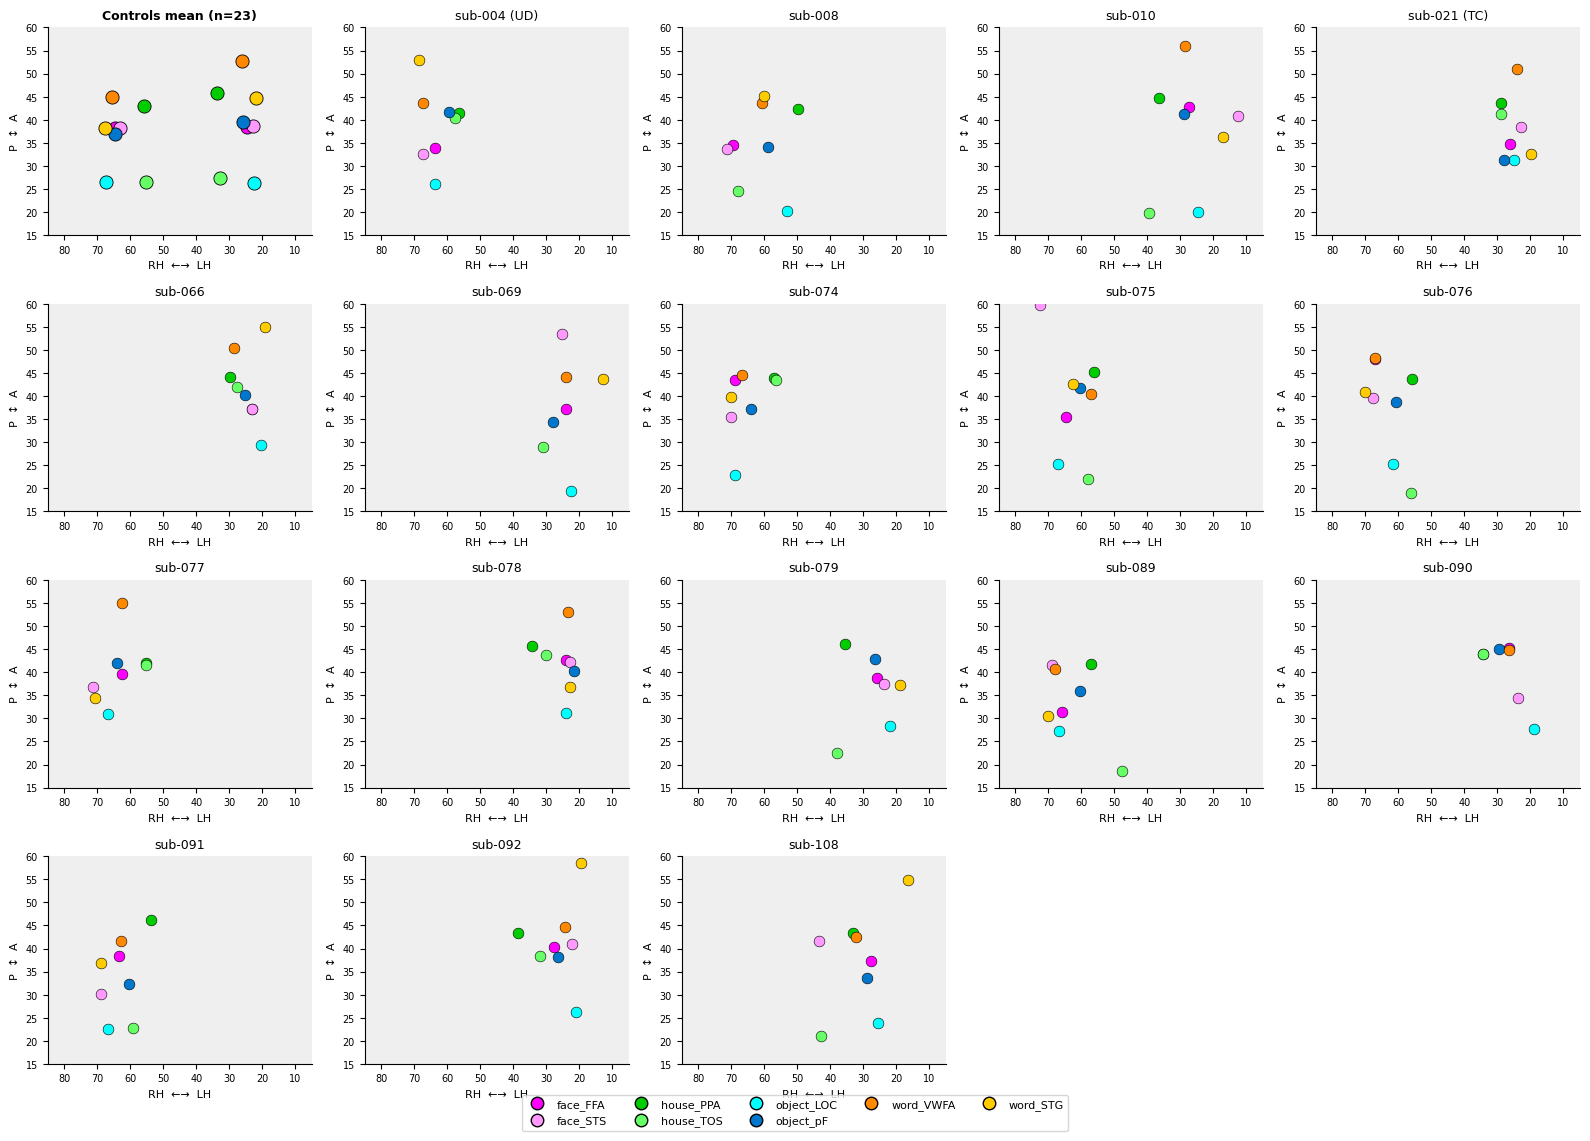

Saved: /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_recreation/liu_fig2CH_spatial_scatter.png


In [45]:
# ROI colors matching Liu style (FFA=magenta, STS=pink, PPA=green, TOS=lt green,
# LOC=cyan, pF=blue, VWFA=orange, STG=yellow)
ROI_COLOR = {
    'face_FFA':    'magenta',  'face_STS':    '#ff99ff',
    'house_PPA':   '#00cc00',  'house_TOS':   '#66ff66',
    'object_LOC':  'cyan',     'object_pF':   '#0077cc',
    'word_VWFA':   '#ff8800',  'word_STG':    '#ffcc00',
}
ALL_CATS = list(ROI_COLOR.keys())

XLIM = (5, 85)
YLIM = (15, 60)   # EVC removed — range tightens

def scatter_subject(ax, df, sub, title):
    for cat in ALL_CATS:
        for h in ('left', 'right'):
            m = df[(df['sub'] == sub) & (df['category'] == cat) & (df['hemi'] == h)]
            if not len(m): continue
            ax.scatter(m['peak_x_mni'].iloc[0], m['peak_y_mni'].iloc[0],
                       s=60, c=ROI_COLOR[cat], edgecolors='k', linewidth=0.4)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.set_xlabel('RH  ←→  LH', fontsize=8)
    ax.set_ylabel('P  ↕  A', fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_facecolor('#efefef')
    ax.tick_params(labelsize=7)
    ax.invert_xaxis()

n_pt = len(otc_subs)
n_cols = 5
n_rows = int(np.ceil((n_pt + 1) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2*n_cols, 2.8*n_rows))
axes = axes.flatten()

# Panel 1: control mean
ax = axes[0]
for cat in ALL_CATS:
    for h in ('left', 'right'):
        xs, ys = [], []
        for s in ctrl_subs:
            m = ctrl_pk[(ctrl_pk['sub'] == s) & (ctrl_pk['category'] == cat) & (ctrl_pk['hemi'] == h)]
            if len(m):
                xs.append(m['peak_x_mni'].iloc[0]); ys.append(m['peak_y_mni'].iloc[0])
        if xs:
            ax.scatter(np.mean(xs), np.mean(ys), s=90, c=ROI_COLOR[cat], edgecolors='k', linewidth=0.6)
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
ax.set_title(f'Controls mean (n={len(ctrl_subs)})', fontsize=9, fontweight='bold')
ax.set_xlabel('RH  ←→  LH', fontsize=8)
ax.set_ylabel('P  ↕  A', fontsize=8)
ax.set_facecolor('#efefef')
ax.tick_params(labelsize=7)
ax.invert_xaxis()

for i, s in enumerate(otc_subs):
    code_s = LIU_CODES.get(s, '')
    label = f'{s} ({code_s})' if code_s else s
    scatter_subject(axes[i+1], pt_pk, s, label)

for j in range(n_pt + 1, len(axes)):
    axes[j].axis('off')

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor='k', markersize=9, label=cat)
                  for cat, c in ROI_COLOR.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_fig2CH_spatial_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/liu_fig2CH_spatial_scatter.png')

### Fig 2I — Crawford's *t* per patient
### Fig 2J — Control null distribution


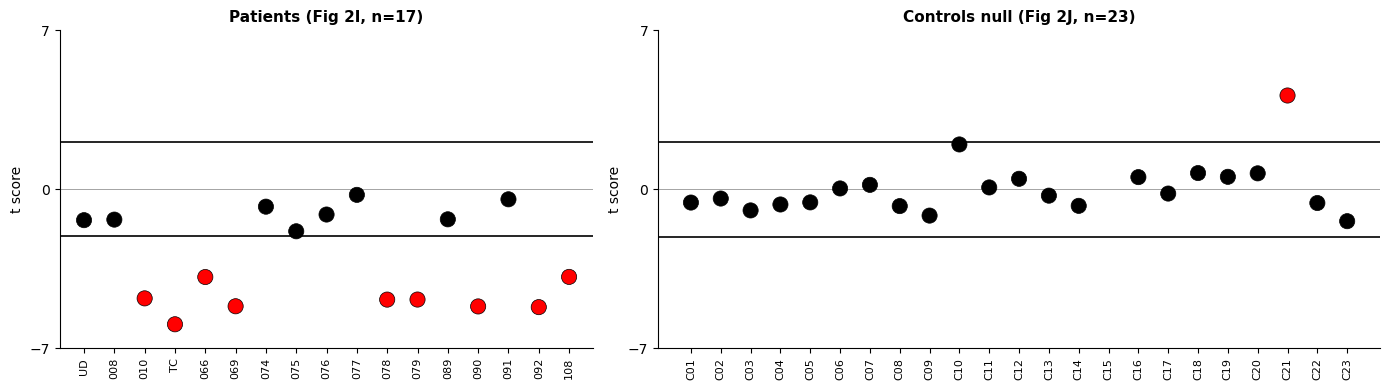

Saved: /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_recreation/liu_fig2IJ_crawford_spatial.png


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         gridspec_kw={'width_ratios': [len(otc_subs), n_ctrl]})

for ax, tvals, subs_labels, crit, title in [
    (axes[0], t_pt,   [LIU_CODES.get(s, s.replace('sub-', '')) for s in otc_subs], crit_pt,   f'Patients (Fig 2I, n={len(otc_subs)})'),
    (axes[1], t_ctrl, [f'C{i+1:02d}' for i in range(n_ctrl)],                      crit_ctrl, f'Controls null (Fig 2J, n={n_ctrl})'),
]:
    xs = np.arange(len(tvals))
    colors = ['red' if (not np.isnan(v) and abs(v) > crit) else 'black' for v in tvals]
    ax.scatter(xs, tvals, s=120, c=colors, edgecolors='k', linewidth=0.5, zorder=3)
    ax.axhline( crit, color='k', lw=1.2)
    ax.axhline(-crit, color='k', lw=1.2)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_ylim(-7, 7); ax.set_yticks([-7, 0, 7])
    ax.set_xticks(xs); ax.set_xticklabels(subs_labels, rotation=90, fontsize=8)
    ax.set_ylabel('t score')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_fig2IJ_crawford_spatial.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/liu_fig2IJ_crawford_spatial.png')


## 4. Fig 3A/B — Example RDMs

Reconstruct 4×4 Pearson-*r* matrices from `pairwise_correlations_differential.csv` by un-Fisher-z'ing: *r* = tanh(fisher_r).

Liu's Fig 3A = lSTG in a control (strong diagonal, low off-diag). Fig 3B = rSTG in TC (strong word preference, weak differentiation).


Control example: sub-057
Patient example: sub-021 (TC)


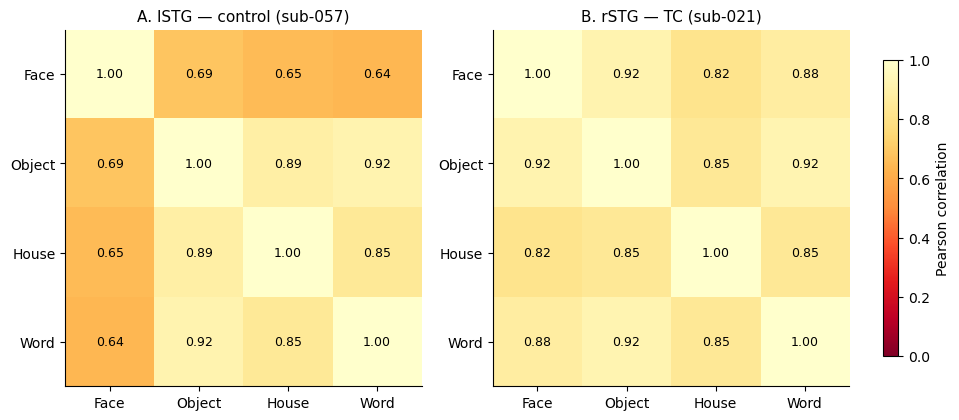

Saved: /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_recreation/liu_fig3AB_example_rdms.png


In [56]:
CATS4 = ['face', 'object', 'house', 'word']   # Liu row/col order


def reconstruct_rdm(subj_pw):
    """Build 4×4 Pearson r from fisher_r pair values."""
    M = np.full((4, 4), np.nan)
    for i, a in enumerate(CATS4):
        for j, b in enumerate(CATS4):
            if i == j:
                M[i, j] = 1.0
                continue
            hit = subj_pw[subj_pw['pair'].isin([f'{a}-{b}', f'{b}-{a}'])]
            if len(hit):
                M[i, j] = np.tanh(hit['fisher_r'].iloc[0])
    return M

# Pick a representative control with lSTG data
ctrl_lstg = ctrl_pw[(ctrl_pw['category'] == 'word_STG') & (ctrl_pw['hemi'] == 'l')]
ctrl_example = sorted(ctrl_lstg['subject_id'].unique())[0] if len(ctrl_lstg) else None
ctrl_example = 'sub-057'

# Patient example: prefer TC (sub-021) for direct Liu comparison; fallback to KN
def get_pt_rdm(sub, cat, hemi):
    q = pt_pw[(pt_pw['subject_id'] == sub) & (pt_pw['category'] == cat) & (pt_pw['hemi'] == hemi)]
    return (reconstruct_rdm(q), q) if len(q) else (None, q)

pt_example_sub = None; pt_rdm = None
for candidate in ['sub-021', 'sub-099', 'sub-044', 'sub-004']:
    pt_rdm, _ = get_pt_rdm(candidate, 'word_STG', 'r')
    if pt_rdm is not None and not np.all(np.isnan(pt_rdm[np.triu_indices(4, k=1)])):
        pt_example_sub = candidate; break

print(f'Control example: {ctrl_example}')
print(f'Patient example: {pt_example_sub} ({LIU_CODES.get(pt_example_sub, "?")})')

ctrl_q = ctrl_pw[(ctrl_pw['subject_id'] == ctrl_example) & (ctrl_pw['category'] == 'word_STG') & (ctrl_pw['hemi'] == 'l')]
ctrl_rdm = reconstruct_rdm(ctrl_q)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
panels = [
    (axes[0], ctrl_rdm, f'A. lSTG — control ({ctrl_example})'),
    (axes[1], pt_rdm,   f'B. rSTG — {LIU_CODES.get(pt_example_sub, pt_example_sub)} ({pt_example_sub})'),
]
for ax, M, ttl in panels:
    im = ax.imshow(M, cmap='YlOrRd_r', vmin=0, vmax=1, aspect='equal')
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(['Face', 'Object', 'House', 'Word'], fontsize=10)
    ax.set_yticklabels(['Face', 'Object', 'House', 'Word'], fontsize=10)
    ax.set_title(ttl, fontsize=11)
    for i in range(4):
        for j in range(4):
            v = M[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=9, color='black' if v > 0.5 else 'white')
cbar = fig.colorbar(im, ax=axes, fraction=0.04, pad=0.04, shrink=0.8)
cbar.set_label('Pearson correlation')
plt.savefig(FIG_DIR / 'liu_fig3AB_example_rdms.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/liu_fig3AB_example_rdms.png')


## 5. Fig 3D — Per-ROI Fisher-z boxplots

Control distribution per ROI (boxplot) with cross-sectional patient markers overlaid. Shape per overlap patient matches Liu: ○=SN, □=TC, ◇=UD, △=KN. Non-overlap patients shown as small dots.


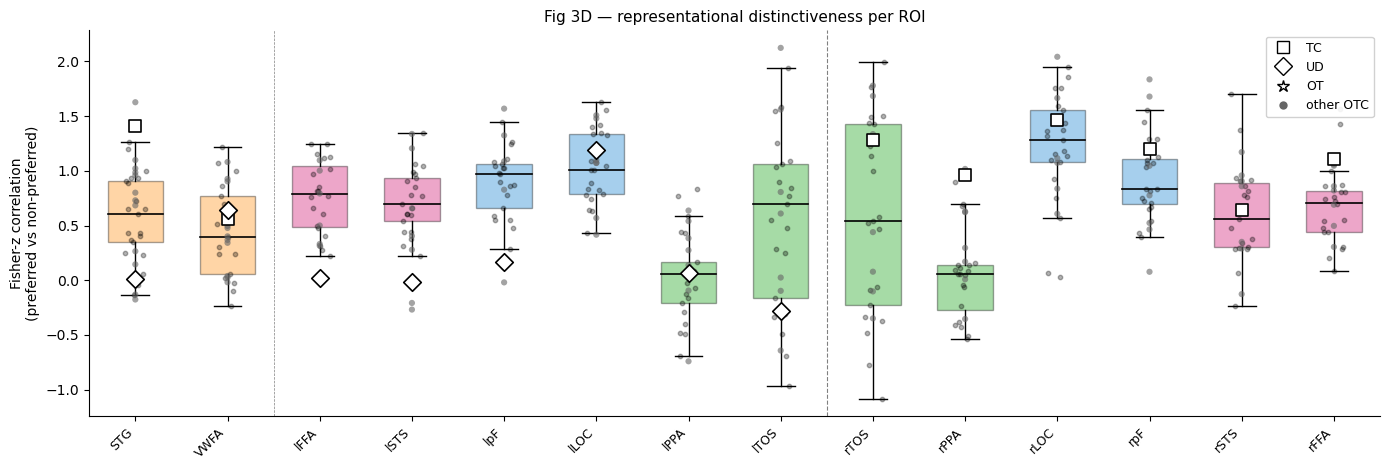

Saved: /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_recreation/liu_fig3D_distinctiveness_box.png


In [65]:
# ROI_ORDER — same structure as Fig 3E
ROI_ORDER = [
    ('word_STG',   'PREF'), ('word_VWFA',  'PREF'),
    ('face_FFA',   'L'),    ('face_STS',   'L'),
    ('object_pF',  'L'),    ('object_LOC', 'L'),
    ('house_PPA',  'L'),    ('house_TOS',  'L'),
    ('house_TOS',  'R'),    ('house_PPA',  'R'),
    ('object_LOC', 'R'),    ('object_pF',  'R'),
    ('face_STS',   'R'),    ('face_FFA',   'R'),
]

def roi_label(cat, hspec):
    short = cat.split('_')[-1]
    if hspec == 'PREF':
        return 'STG' if cat == 'word_STG' else 'VWFA'
    return f'{"l" if hspec == "L" else "r"}{short}'

ROI_CAT_COLOR = {
    'word_STG': '#ff8800',  'word_VWFA': '#ff8800',
    'face_FFA': '#cc0066',  'face_STS':  '#cc0066',
    'object_pF': '#0077cc', 'object_LOC':'#0077cc',
    'house_PPA': '#009900', 'house_TOS': '#009900',
}

# Liu overlap markers (filled white, black edge, distinct shapes)
PT_MARKERS = {'sub-021': ('s', 'TC'), 'sub-004': ('D', 'UD'), 'sub-007': ('*', 'OT')}

intact_map_liu = dict(zip(pt_pk['sub'], pt_pk['intact_hemi']))

def resolve_liu_hemi(hspec, sub, is_control):
    if hspec == 'L': return 'l'
    if hspec == 'R': return 'r'
    if hspec == 'PREF':
        if is_control: return 'l'
        intact = intact_map_liu.get(sub)
        return 'l' if intact == 'left' else 'r' if intact == 'right' else None
    return None

def get_val(df, sub, cat, hemi):
    row = df[(df['subject_id']==sub) & (df['category']==cat) & (df['hemi']==hemi)]
    if not len(row): return np.nan
    return row['liu_distinctiveness'].iloc[0]

# Collect per-slot control distributions + patient values
ctrl_by_slot = []   # list of arrays
pt_by_slot   = []   # list of dicts {sub: value}

for cat, hspec in ROI_ORDER:
    ctrl_vals = []
    for sub in sorted(ctrl_liu['subject_id'].unique()):
        h = resolve_liu_hemi(hspec, sub, True)
        if h is None: continue
        v = get_val(ctrl_liu, sub, cat, h)
        if not np.isnan(v): ctrl_vals.append(v)
    ctrl_by_slot.append(np.array(ctrl_vals))

    pt_vals = {}
    for sub in sorted(pt_liu[pt_liu['group']=='OTC']['subject_id'].unique()):
        h = resolve_liu_hemi(hspec, sub, False)
        if h is None: continue
        v = get_val(pt_liu, sub, cat, h)
        if not np.isnan(v): pt_vals[sub] = v
    pt_by_slot.append(pt_vals)

# Plot
fig, ax = plt.subplots(figsize=(14, 4.8))
positions = np.arange(len(ROI_ORDER))

box_data, box_positions, box_colors = [], [], []
for i, (cat, hspec) in enumerate(ROI_ORDER):
    if len(ctrl_by_slot[i]) >= 3:
        box_data.append(ctrl_by_slot[i])
        box_positions.append(i)
        box_colors.append(ROI_CAT_COLOR[cat])

bp = ax.boxplot(box_data, positions=box_positions, widths=0.6,
                patch_artist=True, showfliers=False,
                medianprops=dict(color='black', lw=1.2),
                whiskerprops=dict(color='black'), capprops=dict(color='black'))
for patch, col in zip(bp['boxes'], box_colors):
    patch.set_facecolor(col); patch.set_alpha(0.35); patch.set_edgecolor('black')

# Control individual dots
for i, vals in enumerate(ctrl_by_slot):
    if len(vals):
        jitter = np.random.RandomState(42 + i).uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(i + jitter, vals, s=10, c='black', alpha=0.3, zorder=2)

# Patient overlay — Liu-named patients with unique markers
for pt_sub, (marker, code) in PT_MARKERS.items():
    for i, pt_vals in enumerate(pt_by_slot):
        if pt_sub in pt_vals:
            ax.scatter(i, pt_vals[pt_sub], marker=marker, s=80,
                       facecolor='white', edgecolor='black', linewidth=1.2, zorder=5)

# Other OTC patients — small gray dots
other_pt = [s for s in pt_liu[pt_liu['group']=='OTC']['subject_id'].unique()
            if s not in PT_MARKERS]
for pt_sub in other_pt:
    for i, pt_vals in enumerate(pt_by_slot):
        if pt_sub in pt_vals:
            ax.scatter(i, pt_vals[pt_sub], marker='o', s=20,
                       facecolor='#666666', edgecolor='none', alpha=0.6, zorder=4)

ax.axvline(1.5, color='gray', lw=0.5, ls='--')          # divider after PREF slots
ax.axvline(7.5, color='gray', lw=0.8, ls='--')          # L/R divider
ax.set_xticks(positions)
ax.set_xticklabels([roi_label(c, h) for c, h in ROI_ORDER], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Fisher-z correlation\n(preferred vs non-preferred)', fontsize=10)
ax.set_title('Fig 3D — representational distinctiveness per ROI', fontsize=11)

from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0], marker=m, color='w', markerfacecolor='white',
                       markeredgecolor='black', markersize=9, label=code)
                for _, (m, code) in PT_MARKERS.items()]
legend_elems.append(Line2D([0],[0], marker='o', color='w', markerfacecolor='#666666',
                           markeredgecolor='none', markersize=6, label='other OTC'))
ax.legend(handles=legend_elems, loc='upper right', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_fig3D_distinctiveness_box.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/liu_fig3D_distinctiveness_box.png')

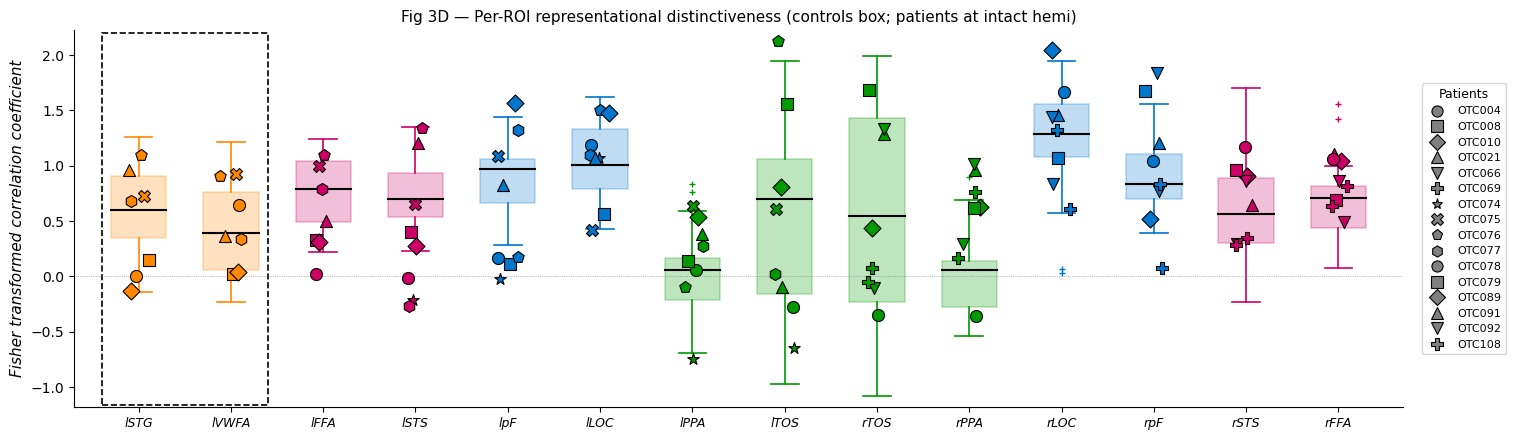

Saved: liu_fig3d_per_roi.png — y range [-1.18, 2.22]


In [69]:
# ═══════════════════════════════════════════════════════════════════════════════
# Figure: Per-ROI Liu Distinctiveness (cf. Liu et al. 2025, Fig 3D)
# Boxplots of controls; patient markers overlaid at intact hemi only, with jitter.
# ═══════════════════════════════════════════════════════════════════════════════

liu_full = pd.read_csv(LIU_DIR / f'liu_distinctiveness_{COPE_SET}.csv')
liu_full = liu_full[~liu_full['subject_id'].isin(EXCLUDE)]
liu_full['ses_num'] = pd.to_numeric(liu_full['session'], errors='coerce').astype(int)

ctrl_fs = liu_full[liu_full['status']=='control'].copy()
fs = ctrl_fs.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num':'fs'})
ctrl_fs = ctrl_fs.merge(fs, on='subject_id')
ctrl_fs = ctrl_fs[ctrl_fs['ses_num']==ctrl_fs['fs']]

pt_full = liu_full[liu_full['group']=='OTC'].copy()
ls = pt_full.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num':'ls'})
pt_full = pt_full.merge(ls, on='subject_id')
pt_full = pt_full[pt_full['ses_num']==pt_full['ls']]

SUB_ROIS_L = [('word_STG','left'),('word_VWFA','left'),
              ('face_FFA','left'),('face_STS','left'),
              ('object_pF','left'),('object_LOC','left'),
              ('house_PPA','left'),('house_TOS','left')]
SUB_ROIS_R = [('house_TOS','right'),('house_PPA','right'),
              ('object_LOC','right'),('object_pF','right'),
              ('face_STS','right'),('face_FFA','right')]
ROI_ORDER = SUB_ROIS_L + SUB_ROIS_R

def roi_label(roi, hemi):
    return f'{"l" if hemi=="left" else "r"}{roi.split("_")[-1]}'

ROI_COLORS = {
    'word_STG':'#ff8800','word_VWFA':'#ff8800',
    'face_FFA':'#cc0066','face_STS':'#cc0066',
    'object_pF':'#0077cc','object_LOC':'#0077cc',
    'house_PPA':'#009900','house_TOS':'#009900',
}

_marker_cycle = ['o','s','D','^','v','P','*','X','p','h']
PT_MARKERS = {}
for i, sub in enumerate(sorted(pt_full['subject_id'].unique())):
    code = pt_full[pt_full['subject_id']==sub]['subject'].iloc[0] if 'subject' in pt_full.columns else sub
    PT_MARKERS[sub] = {'marker': _marker_cycle[i % len(_marker_cycle)], 'label': code}

VCOL = 'liu_distinctiveness'
JITTER = 0.12
rng = np.random.RandomState(42)

n_rois = len(ROI_ORDER)
fig, ax = plt.subplots(figsize=(max(16, n_rois*0.9), 4.5))
positions = np.arange(n_rois)
xlabels = []

all_vals = liu_full[liu_full['category'].isin([r for r,_ in ROI_ORDER])][VCOL].dropna()
y_min, y_max = all_vals.min()-0.1, all_vals.max()+0.1

for xi, (roi, hemi) in enumerate(ROI_ORDER):
    color = ROI_COLORS[roi]
    xlabels.append(roi_label(roi, hemi))

    ctrl_vals = ctrl_fs[(ctrl_fs['category']==roi) &
                        (ctrl_fs['hemi_label']==hemi)][VCOL].dropna().values
    if len(ctrl_vals) == 0: continue

    ax.boxplot(ctrl_vals, positions=[xi], widths=0.6, patch_artist=True,
               showfliers=True, flierprops={'marker':'+','ms':5,'mec':color},
               medianprops={'color':'black','lw':1.5},
               whiskerprops={'color':color,'lw':1.2},
               capprops={'color':color,'lw':1.2},
               boxprops={'facecolor':color,'alpha':0.25,'edgecolor':color,'lw':1.2})

    for sub in pt_full['subject_id'].unique():
        sd = pt_full[pt_full['subject_id']==sub]
        if sd.empty: continue
        surgery = sd['surgery_side'].iloc[0] if 'surgery_side' in sd.columns else ''
        intact = 'left' if surgery=='right' else 'right'
        if intact != hemi: continue
        val = sd[(sd['category']==roi) & (sd['hemi_label']=='intact')][VCOL].values
        if len(val)==0: continue
        mi = PT_MARKERS[sub]
        x_jit = xi + rng.uniform(-JITTER, JITTER)
        ax.scatter(x_jit, val[0], marker=mi['marker'], s=75, zorder=5,
                   edgecolors='black', linewidth=0.8, facecolors=color)

ax.set_xticks(positions)
ax.set_xticklabels(xlabels, fontsize=9, fontstyle='italic')
ax.set_ylabel('Fisher transformed correlation coefficient', fontsize=11, fontstyle='italic')
ax.set_xlim(-0.7, n_rois-0.3); ax.set_ylim(y_min, y_max)
ax.axhline(0, color='gray', lw=0.5, ls=':')

# Dashed box around lSTG, lVWFA (Liu convention — word-lateralized ROIs)
rect = plt.Rectangle((-0.4, y_min+0.02), 1.8, y_max-y_min-0.04,
                     fill=False, edgecolor='black', linestyle='--', linewidth=1.2)
ax.add_patch(rect)

handles = [plt.Line2D([0],[0], marker=mi['marker'], color='gray', linestyle='None',
                      ms=8, mec='black', mew=0.8, label=mi['label'])
           for sub, mi in PT_MARKERS.items()]
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=8, frameon=True, title='Patients', title_fontsize=9)

plt.title('Fig 3D — Per-ROI representational distinctiveness (controls box; patients at intact hemi)',
          fontsize=11)
plt.tight_layout()
plt.subplots_adjust(right=0.88)
plt.savefig(str(FIG_DIR / 'liu_fig3d_per_roi.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: liu_fig3d_per_roi.png — y range [{y_min:.2f}, {y_max:.2f}]')

## 6. Fig 3E — Per-ROI Crawford's *t*


n_ctrl per ROI: min=17, max=21
Critical t (α=.05, 2-sided, min df=16): ±2.120



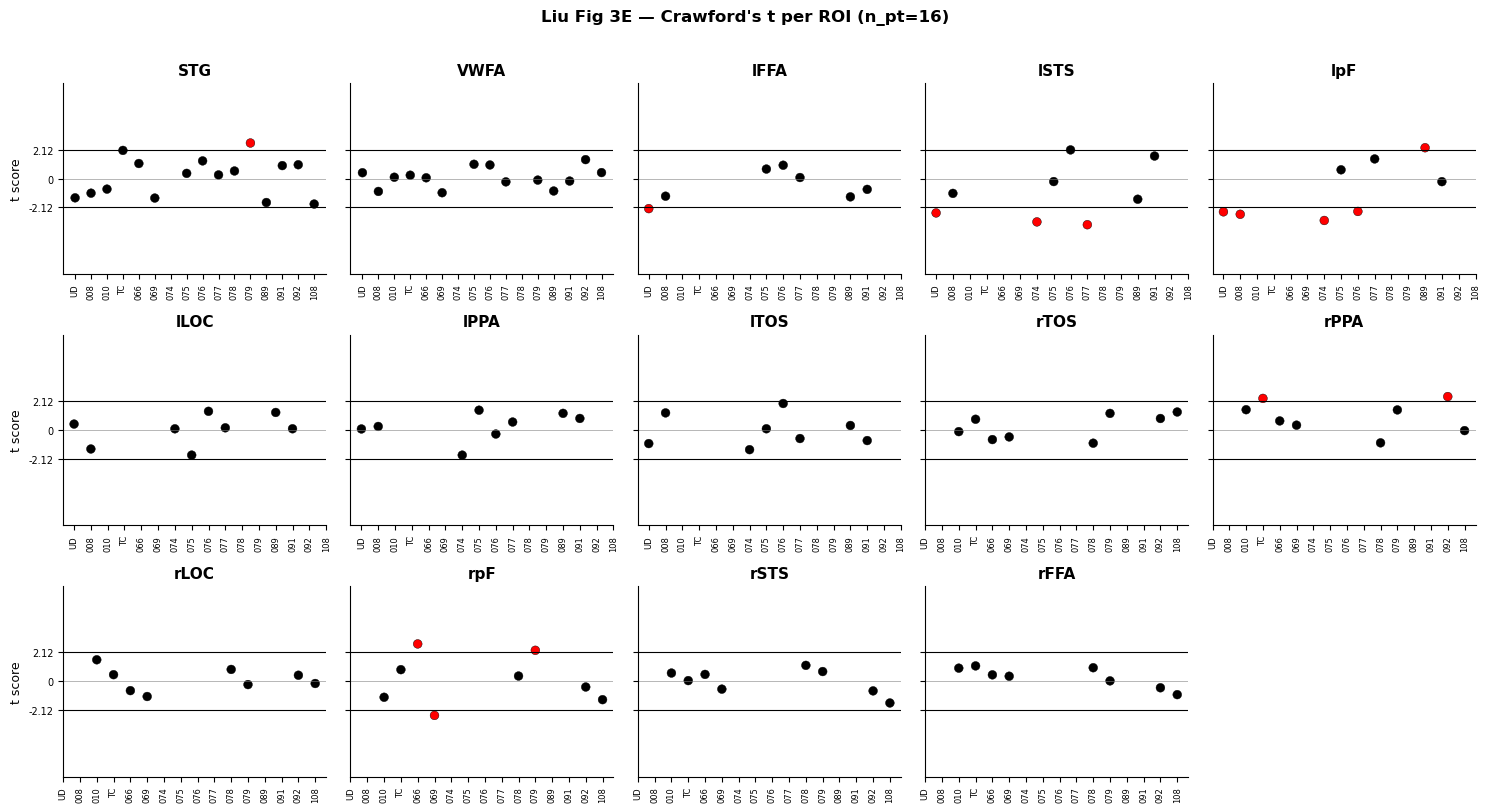

In [59]:
# ROI_ORDER with hemi spec: 'L'/'R' = fixed, 'PREF' = l for ctrl / intact for pt
ROI_ORDER = [
    ('word_STG',   'PREF'),      # STG — wherever lateralized
    ('word_VWFA',  'PREF'),      # VWFA — wherever lateralized
    ('face_FFA',   'L'), ('face_STS',   'L'),
    ('object_pF',  'L'), ('object_LOC', 'L'),
    ('house_PPA',  'L'), ('house_TOS',  'L'),
    ('house_TOS',  'R'), ('house_PPA',  'R'),
    ('object_LOC', 'R'), ('object_pF',  'R'),
    ('face_STS',   'R'), ('face_FFA',   'R'),
]

def roi_label(cat, hspec):
    short = cat.split('_')[-1]
    if hspec == 'PREF':
        return 'STG' if cat == 'word_STG' else 'VWFA'
    return f'{"l" if hspec == "L" else "r"}{short}'

ROI_CAT_COLOR = {
    'word_STG': '#ff8800', 'word_VWFA': '#ff8800',
    'face_FFA': '#cc0066', 'face_STS': '#cc0066',
    'object_pF': '#0077cc', 'object_LOC': '#0077cc',
    'house_PPA': '#009900', 'house_TOS': '#009900',
}

# Lookup: intact hemi per patient (from liu_full since peak_pk is spatial only)
intact_map_liu = dict(zip(pt_pk['sub'], pt_pk['intact_hemi']))

def resolve_liu_hemi(hspec, sub, is_control):
    if hspec == 'L': return 'l'
    if hspec == 'R': return 'r'
    if hspec == 'PREF':
        if is_control: return 'l'
        intact = intact_map_liu.get(sub)
        return 'l' if intact == 'left' else 'r' if intact == 'right' else None
    return None

# Recompute Crawford t per (ROI, patient) with hemi-flexible lookup
pt_subs_liu = sorted(pt_liu[pt_liu['group'] == 'OTC']['subject_id'].unique())
n_rois = len(ROI_ORDER)
n_pt_liu = len(pt_subs_liu)
t_mat = np.full((n_rois, n_pt_liu), np.nan)
p_mat = np.full((n_rois, n_pt_liu), np.nan)
n_ctrls_roi = np.zeros(n_rois, dtype=int)

for r, (cat, hspec) in enumerate(ROI_ORDER):
    # Control values — resolve hemi for each control (PREF → 'l' for all ctrls)
    ctrl_vals = []
    for sub in sorted(ctrl_liu['subject_id'].unique()):
        h = resolve_liu_hemi(hspec, sub, is_control=True)
        if h is None: continue
        row = ctrl_liu[(ctrl_liu['subject_id'] == sub) &
                       (ctrl_liu['category'] == cat) &
                       (ctrl_liu['hemi'] == h)]
        if len(row) and not np.isnan(row['liu_distinctiveness'].iloc[0]):
            ctrl_vals.append(row['liu_distinctiveness'].iloc[0])
    ctrl_vals = np.array(ctrl_vals)
    n_ctrls_roi[r] = len(ctrl_vals)
    if len(ctrl_vals) < 2: continue
    m, sd = np.mean(ctrl_vals), np.std(ctrl_vals, ddof=1)
    if sd == 0: continue
    # Patient values — resolve hemi per patient
    for p, sub in enumerate(pt_subs_liu):
        h = resolve_liu_hemi(hspec, sub, is_control=False)
        if h is None: continue
        row = pt_liu[(pt_liu['subject_id'] == sub) &
                     (pt_liu['category'] == cat) &
                     (pt_liu['hemi'] == h)]
        if not len(row): continue
        x = row['liu_distinctiveness'].iloc[0]
        if np.isnan(x): continue
        n = len(ctrl_vals)
        t_mat[r, p] = (x - m) / (sd * np.sqrt((n + 1) / n))
        p_mat[r, p] = 2 * (1 - tdist.cdf(abs(t_mat[r, p]), df=n - 1))

min_df = max(int(n_ctrls_roi.min()) - 1, 1)
crit_3E = float(tdist.ppf(0.975, df=min_df))
print(f'n_ctrl per ROI: min={n_ctrls_roi.min()}, max={n_ctrls_roi.max()}')
print(f'Critical t (α=.05, 2-sided, min df={min_df}): ±{crit_3E:.3f}\n')

# Plot (unchanged from original Cell 17 plot block below — just rerun it)
fig, axes = plt.subplots(3, 5, figsize=(15, 8), sharey=True)
axes = axes.flatten()
pt_labels = [LIU_CODES.get(s, s.replace('sub-', '')) for s in pt_subs_liu]
for r, (cat, hspec) in enumerate(ROI_ORDER):
    ax = axes[r]
    xs = np.arange(n_pt_liu)
    tvals = t_mat[r]
    colors = ['red' if (not np.isnan(v) and abs(v) > crit_3E) else 'black' for v in tvals]
    ax.scatter(xs, tvals, s=40, c=colors, edgecolors='k', linewidth=0.3)
    ax.axhline( crit_3E, color='k', lw=0.8); ax.axhline(-crit_3E, color='k', lw=0.8)
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylim(-7, 7); ax.set_yticks([-crit_3E, 0, crit_3E])
    ax.set_yticklabels([f'{-crit_3E:.2f}', '0', f'{crit_3E:.2f}'], fontsize=7)
    ax.set_xticks(xs); ax.set_xticklabels(pt_labels, rotation=90, fontsize=6)
    ax.set_title(roi_label(cat, hspec), fontsize=11, fontweight='bold')
    if r % 5 == 0: ax.set_ylabel('t score', fontsize=9)
for r in range(n_rois, len(axes)): axes[r].axis('off')
plt.suptitle(f'Liu Fig 3E — Crawford\'s t per ROI (n_pt={n_pt_liu})', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_fig3E_crawford_per_roi.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Validation against Liu (2025)

Direct spot-check of our 4 overlap patients against Liu's published figure pattern. If our pipeline is faithful, we should recover the same qualitative pattern.

**Liu's published pattern (read from Fig 2I and Fig 3E):**

| Patient | Fig 2I | Fig 3E (ROIs with red dots in Liu) |
|---|---|---|
| KN (sub-010) | red, large negative t | IFG, STG, VWFA, rPPA |
| TC (sub-021) | red, negative t | (mostly black) |
| UD (sub-004) | black (n.s.) | (all black) |

SN not in sample (would need L-temporal evacuation patient); OT was outside-VOTC control patient.

If our pattern diverges substantially for all three, the pipeline needs inspection. Small deviations are expected (different registration, different search-mask definition, IFG excluded from our set, and KN mapping is tentative).


In [70]:
print(f'{"="*78}')
print(f'VALIDATION: Liu overlap patients — Fig 2I (spatial Crawford\'s t)')
print(f'{"="*78}')
print(f'{"liu":<6}{"sub":<12}{"our t":>10}{"our p":>10}{"our sig":>10}{"Liu expect":>14}{"match":>8}')
expected_2I = {'sub-010': 'sig', 'sub-021': 'sig', 'sub-004': 'n.s.'}
for sub, code_s in LIU_CODES.items():
    if sub not in otc_subs:
        print(f'{code_s:<6}{sub:<12}{"(not in OTC sample)":<40}')
        continue
    p_idx = otc_subs.index(sub)
    t_val = t_pt[p_idx]; p_val = p_pt[p_idx]
    our_sig = 'sig' if not np.isnan(t_val) and abs(t_val) > crit_pt else 'n.s.'
    expected = expected_2I[sub]
    match = '✓' if our_sig == expected else '✗'
    print(f'{code_s:<6}{sub:<12}{t_val:>10.3f}{p_val:>10.3f}{our_sig:>10}{expected:>14}{match:>8}')


VALIDATION: Liu overlap patients — Fig 2I (spatial Crawford's t)
liu   sub              our t     our p   our sig    Liu expect   match
UD    sub-004         -1.359     0.188      n.s.          n.s.       ✓
TC    sub-021         -5.943     0.000       sig           sig       ✓
OT    sub-007     (not in OTC sample)                     


In [71]:
# Fig 3E validation — which ROIs each overlap patient has |t|>crit
print(f'{"="*78}')
print(f'VALIDATION: Liu overlap patients — Fig 3E (per-ROI Crawford\'s t)')
print(f'{"="*78}')
expected_3E = {
    'sub-010': ['rPPA'],          # KN
    'sub-021': ['STG', 'VWFA'],   # TC
    'sub-004': [],                # UD
}
for sub, code_s in LIU_CODES.items():
    if sub not in pt_subs_liu:
        print(f'{code_s}/{sub}: (not in Liu-distinctiveness sample)')
        continue
    p_idx = pt_subs_liu.index(sub)
    sig_rois = [roi_label(ROI_ORDER[r][0], ROI_ORDER[r][1])
                for r in range(n_rois)
                if not np.isnan(t_mat[r, p_idx]) and abs(t_mat[r, p_idx]) > crit_3E]
    exp = expected_3E[sub]
    overlap = set(sig_rois) & set(exp)
    print(f'\n{code_s} ({sub}):')
    print(f'  our |t|>crit : {sig_rois if sig_rois else "(none)"}')
    print(f'  Liu published: {exp if exp else "(none)"}')
    print(f'  overlap      : {sorted(overlap) if overlap else "(none)"}')

VALIDATION: Liu overlap patients — Fig 3E (per-ROI Crawford's t)

UD (sub-004):
  our |t|>crit : ['lFFA', 'lSTS', 'lpF']
  Liu published: (none)
  overlap      : (none)

TC (sub-021):
  our |t|>crit : ['rPPA']
  Liu published: ['STG', 'VWFA']
  overlap      : (none)
OT/sub-007: (not in Liu-distinctiveness sample)


In [72]:
# Export Crawford t values per overlap patient per ROI for manual inspection
rows = []
for p, sub in enumerate(pt_subs_liu):
    if sub not in LIU_CODES: continue
    for r, (cat, hspec) in enumerate(ROI_ORDER):
        h = resolve_liu_hemi(hspec, sub, is_control=False)
        row = pt_liu[(pt_liu['subject_id']==sub) & (pt_liu['category']==cat) & (pt_liu['hemi']==h)] if h else pd.DataFrame()
        rows.append({
            'liu_code':        LIU_CODES[sub],
            'subject':         sub,
            'roi':             roi_label(cat, hspec),
            'category':        cat,
            'hemi_spec':       hspec,
            'hemi_resolved':   h,
            'distinctiveness': row['liu_distinctiveness'].iloc[0] if len(row) else np.nan,
            'crawford_t':      t_mat[r, p],
            'crawford_p':      p_mat[r, p],
            'n_ctrl':          int(n_ctrls_roi[r]),
            'sig':             '*' if not np.isnan(t_mat[r, p]) and abs(t_mat[r, p]) > crit_3E else '',
        })

val_df = pd.DataFrame(rows)
out_csv = FIG_DIR / 'overlap_patient_validation.csv'
val_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}\n')
print(val_df.to_string(index=False))

Saved: /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_recreation/overlap_patient_validation.csv

liu_code subject   roi   category hemi_spec hemi_resolved  distinctiveness  crawford_t  crawford_p  n_ctrl sig
      UD sub-004  lSTG   word_STG      left          None              NaN   -1.412824    0.173081      21    
      UD sub-004 lVWFA  word_VWFA      left          None              NaN    0.432597    0.671082      17    
      UD sub-004  lFFA   face_FFA      left          None              NaN   -2.207143    0.039803      20   *
      UD sub-004  lSTS   face_STS      left          None              NaN   -2.522671    0.020229      21   *
      UD sub-004   lpF  object_pF      left          None              NaN   -2.440367    0.024104      21   *
      UD sub-004  lLOC object_LOC      left          None              NaN    0.430995    0.671082      21    
      UD sub-004  lPPA  house_PPA      left          None              NaN    0.071729    0.943530      21    
   

## 8. Next steps (if validation passes)

1. Confirm 4/4 overlap patients match Liu's Fig 2I pattern.
2. Confirm KN's Fig 3E hits align with ours (STG, VWFA, rPPA; IFG dropped).
3. Once validated, the novel contribution is: *same pipeline, 12 additional cross-sectional patients*, including R-resection subgroup.
4. Figures to send Marlene: `liu_fig2CH_spatial_scatter.png`, `liu_fig2IJ_crawford_spatial.png`, `liu_fig3AB_example_rdms.png`, `liu_fig3D_boxplots.png`, `liu_fig3E_crawford_per_roi.png`.


In [73]:
print(f'n_rois: {n_rois}, n_pt_liu: {n_pt_liu}, t_mat shape: {t_mat.shape}')
print(f't_mat non-NaN count: {(~np.isnan(t_mat)).sum()}')
print(f'n_ctrls_roi: {n_ctrls_roi}')
print(f'\nTC row-by-row:')
p_idx = pt_subs_liu.index('sub-021')
for r, (cat, hspec) in enumerate(ROI_ORDER):
    print(f'  {roi_label(cat, hspec):<8}  t={t_mat[r, p_idx]:.3f}  (cat={cat}, hspec={hspec})')
print(f'\ncrit_3E: {crit_3E}')

n_rois: 14, n_pt_liu: 16, t_mat shape: (14, 16)
t_mat non-NaN count: 124
n_ctrls_roi: [21 17 20 21 21 21 21 21 21 20 21 20 19 20]

TC row-by-row:
  lSTG      t=2.072  (cat=word_STG, hspec=left)
  lVWFA     t=0.249  (cat=word_VWFA, hspec=left)
  lFFA      t=nan  (cat=face_FFA, hspec=left)
  lSTS      t=nan  (cat=face_STS, hspec=left)
  lpF       t=nan  (cat=object_pF, hspec=left)
  lLOC      t=nan  (cat=object_LOC, hspec=left)
  lPPA      t=nan  (cat=house_PPA, hspec=left)
  lTOS      t=nan  (cat=house_TOS, hspec=left)
  rTOS      t=0.784  (cat=house_TOS, hspec=right)
  rPPA      t=2.316  (cat=house_PPA, hspec=right)
  rLOC      t=0.484  (cat=object_LOC, hspec=right)
  rpF       t=0.853  (cat=object_pF, hspec=right)
  rSTS      t=0.048  (cat=face_STS, hspec=right)
  rFFA      t=1.129  (cat=face_FFA, hspec=right)

crit_3E: 2.1199052992210112
